# D2C Customer Churn Intelligence & Retention API

## Part 3: Customer Churn Prediction Model

### Student Details

**Name:** Mayank Sharma

**Student_ID:** iitp_aiml_2506012

---

## Objective

The objective of this analysis is to develop a machine learning model capable of identifying customers who are likely to churn within the next 60 days.

Customer churn represents a significant business challenge because acquiring new customers is often more expensive than retaining existing ones. Early identification of churn-prone customers allows the organization to deploy targeted retention campaigns, improve customer engagement, and reduce revenue loss.

This analysis combines customer purchasing behaviour, support interactions, return activity, campaign engagement, loyalty indicators, and other behavioural signals to build predictive models that estimate churn probability.

The analysis aims to:

- Prepare a customer-level modeling dataset
- Prevent data leakage through proper feature selection
- Train multiple machine learning models
- Compare baseline and advanced models
- Evaluate model performance using business-relevant metrics
- Optimize classification thresholds for retention decisions
- Interpret key drivers of churn
- Analyze prediction errors using real customer examples
- Develop a production-ready churn prediction framework
- Support business retention planning through data-driven insights

---

## Expected Deliverables

1. Customer Modeling Dataset
2. Leakage Prevention Validation
3. Train / Validation / Test Split
4. Baseline Machine Learning Model
5. Multiple Advanced Machine Learning Models
6. Model Performance Comparison
7. Threshold Optimization Analysis
8. Feature Importance & Explainability Analysis
9. Customer-Level Error Analysis
10. Final Trained Model Files
11. Metrics Summary Report
12. Model Card Documentation
13. Business Recommendations

# Project Workflow

The churn prediction pipeline follows the following workflow:

1. Import Required Libraries
2. Configure Project Paths
3. Load Modeling Dataset
4. Understand Dataset Structure
5. Validate Data Quality
6. Check for Data Leakage
7. Feature Selection
8. Data Preprocessing
9. Train / Validation / Test Split
10. Baseline Model Development
11. Advanced Model Development
12. Cross Validation
13. Model Evaluation
14. Threshold Optimization
15. Feature Importance Analysis
16. Error Analysis
17. Model Saving

# Importing Required Libraries

This section imports all libraries required for:

- Data manipulation
- Data visualization
- Machine learning model development
- Model evaluation
- Hyperparameter optimization
- Model persistence
- Explainability and interpretation

In [7]:
# ==========================================================
# DATA MANIPULATION
# ==========================================================

import pandas as pd
import numpy as np

# ==========================================================
# VISUALIZATION
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# MACHINE LEARNING UTILITIES
# ==========================================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# ==========================================================
# EVALUATION METRICS
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# ==========================================================
# BASELINE MODEL
# ==========================================================

from sklearn.linear_model import LogisticRegression

# ==========================================================
# ADVANCED MODELS
# ==========================================================

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.ensemble import ExtraTreesClassifier

# ==========================================================
# MODEL SAVING
# ==========================================================

import joblib

# ==========================================================
# SYSTEM UTILITIES
# ==========================================================

import json
import warnings

from pathlib import Path

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


# Configuring Project Directories

Separate folders are maintained for model artifacts and output reports.

This ensures reproducibility and allows evaluators to easily locate generated files.

In [8]:
# ==========================================================
# PROJECT PATHS
# ==========================================================

DATA_PATH = Path("../Datasets")

OUTPUT_PATH = Path("Part_3_outputs")

MODEL_PATH = Path("Models")

OUTPUT_PATH.mkdir(
    exist_ok=True
)

MODEL_PATH.mkdir(
    exist_ok=True
)

print("Data Path    :", DATA_PATH)
print("Output Path  :", OUTPUT_PATH)
print("Model Path   :", MODEL_PATH)

Data Path    : ..\Datasets
Output Path  : Part_3_outputs
Model Path   : Models


# Loading Modeling Dataset

The churn prediction task can be performed using either:

1. The provided modeling snapshot dataset
2. A custom feature table created from raw customer datasets

Before proceeding with modeling, all available files will be inspected to identify the appropriate dataset.

In [9]:
# ==========================================================
# VIEW AVAILABLE FILES
# ==========================================================

import os

for root, dirs, files in os.walk(DATA_PATH):
    
    for file in files:
        
        print(file)

churn_labels.csv
customers.csv
DATA_DICTIONARY.md
intervention_history.csv
orders.csv
rfm_modeling_snapshot.csv
STUDENT_FACING_PROBLEM_STATEMENT.md
support_tickets.csv
web_events_snapshot.csv


# Loading Modeling Snapshot Dataset

The churn prediction task requires a customer-level modeling table containing historical customer behaviour and the target churn label.

The provided modeling snapshot dataset contains customer features that were generated before the prediction window and is therefore suitable for machine learning model development.

This dataset will serve as the primary modeling table for all subsequent analysis and model training activities.

In [10]:
# ==========================================================
# LOAD MODELING DATASET
# ==========================================================

modeling_df = pd.read_csv(
    DATA_PATH / "rfm_modeling_snapshot.csv"
)

print("Dataset Loaded Successfully")
print()

print("Rows    :", modeling_df.shape[0])
print("Columns :", modeling_df.shape[1])

Dataset Loaded Successfully

Rows    : 2400
Columns : 29


# Preview Dataset

Before building machine learning models, it is important to inspect the structure of the dataset.

This step helps verify:

- Available features
- Feature naming conventions
- Data types
- Potential target variables
- General data quality

In [11]:
# ==========================================================
# FIRST FIVE RECORDS
# ==========================================================

modeling_df.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


# Dataset Structure Overview

This section provides a high-level summary of the dataset including:

- Number of observations
- Number of variables
- Feature names
- Data types

Understanding the dataset structure is essential for feature engineering and model preparation.

In [12]:
# ==========================================================
# DATASET STRUCTURE
# ==========================================================

print("Dataset Shape")
print(modeling_df.shape)

print("\nColumn Names")
print(list(modeling_df.columns))

print("\nData Types")
print(modeling_df.dtypes)

Dataset Shape
(2400, 29)

Column Names
['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

Data Types
customer_id                  object
snapshot_date                object
city_tier                    object
age_group                    object
acquisition_channel          object
loyalty_tier                 object
preferred_category           object
marketing_consent            object
recency_days                  int64
frequency_180d                int64
monetary_180d      

# Statistical Summary

Descriptive statistics help identify:

- Feature ranges
- Potential outliers
- Distribution characteristics
- Data consistency

These observations support preprocessing decisions later in the modeling pipeline.

In [13]:
# ==========================================================
# NUMERICAL FEATURE SUMMARY
# ==========================================================

modeling_df.describe().T

,count,mean,std,min,25%,50%,75%,max
recency_days,2400.0,87.375833,80.137473,0.0,25.00,66.000,129.00,562.00
frequency_180d,2400.0,1.594583,1.184964,0.0,1.00,1.000,2.00,8.00
monetary_180d,2400.0,1179.763196,1035.900649,0.0,449.27,911.875,1681.51,6982.41
return_rate_180d,2400.0,0.061505,0.203092,0.0,0.00,0.000,0.00,1.00
avg_discount_pct_180d,2400.0,0.245094,0.139805,0.0,0.16,0.260,0.34,0.70
avg_rating_180d,2400.0,3.847092,0.923442,1.0,3.50,4.000,4.50,5.00
category_diversity_180d,2400.0,1.375417,0.896650,0.0,1.00,1.000,2.00,5.00
ticket_count_90d,2400.0,0.229167,0.471779,0.0,0.00,0.000,0.00,3.00
negative_ticket_rate_90d,2400.0,0.138819,0.343293,0.0,0.00,0.000,0.00,1.00
avg_resolution_hours_90d,2400.0,5.093079,11.845798,0.0,0.00,0.000,0.00,73.80


# Missing Value Analysis

Missing values can negatively affect machine learning models and may require imputation.

This section evaluates:

- Total missing values
- Missing percentage
- Features requiring treatment

In [14]:
# ==========================================================
# MISSING VALUE ANALYSIS
# ==========================================================

missing_summary = pd.DataFrame({
    "missing_count": modeling_df.isna().sum(),
    "missing_percentage": (
        modeling_df.isna().sum()
        / len(modeling_df)
    ) * 100
})

missing_summary = (
    missing_summary
    .sort_values(
        by="missing_count",
        ascending=False
    )
)

missing_summary

,missing_count,missing_percentage
loyalty_tier,1386,57.75
snapshot_date,0,0.00
city_tier,0,0.00
age_group,0,0.00
customer_id,0,0.00
acquisition_channel,0,0.00
preferred_category,0,0.00
marketing_consent,0,0.00
recency_days,0,0.00
frequency_180d,0,0.00


# Duplicate Record Analysis

Duplicate customer records can introduce bias into machine learning models.

This validation ensures that each observation represents a unique customer.

In [15]:
# ==========================================================
# DUPLICATE CHECK
# ==========================================================

duplicate_count = modeling_df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

Duplicate Records : 0


# Customer Identifier Validation

Customer identifiers should uniquely represent customers and must not be used directly as predictive features.

This step verifies the uniqueness of customer records within the modeling dataset.

In [16]:
# ==========================================================
# CUSTOMER ID VALIDATION
# ==========================================================

customer_id_columns = [
    col
    for col in modeling_df.columns
    if "customer" in col.lower()
]

print("Potential Customer ID Columns")
print(customer_id_columns)

for col in customer_id_columns:

    print("\nColumn :", col)

    print(
        "Unique Values :",
        modeling_df[col].nunique()
    )

    print(
        "Total Rows :",
        len(modeling_df)
    )

Potential Customer ID Columns
['customer_id']

Column : customer_id
Unique Values : 2400
Total Rows : 2400


# Initial Observations

Based on the dataset inspection performed above, the following observations can be noted:

### Data Quality Assessment

- Dataset loaded successfully.
- Dataset structure has been verified.
- Missing value patterns have been identified.
- Duplicate records have been evaluated.
- Customer identifier columns have been inspected.

### Next Steps

The next stage focuses on:

1. Identifying the churn target variable.
2. Understanding class distribution.
3. Detecting potential leakage variables.
4. Selecting valid predictive features.
5. Preparing the modeling dataset.

# Target Variable Analysis

The objective of this project is to predict whether a customer will churn within the next 60 days.

Target Variable:

**churn_next_60d**

Interpretation:

- 1 = Customer churned within 60 days after the snapshot date
- 0 = Customer remained active during the prediction window

Before model training, it is important to understand:

- Class distribution
- Churn prevalence
- Potential imbalance issues

This analysis helps determine appropriate evaluation metrics and modeling strategies.

In [17]:
# ==========================================================
# TARGET VARIABLE DISTRIBUTION
# ==========================================================

target_distribution = (
    modeling_df["churn_next_60d"]
    .value_counts()
    .reset_index()
)

target_distribution.columns = [
    "churn_label",
    "customer_count"
]

target_distribution

,churn_label,customer_count
0,0,1273
1,1,1127


In [18]:
# ==========================================================
# TARGET PERCENTAGES
# ==========================================================

churn_rate = (
    modeling_df["churn_next_60d"]
    .mean()
)

print(
    f"Overall Churn Rate : {churn_rate:.2%}"
)

Overall Churn Rate : 46.96%


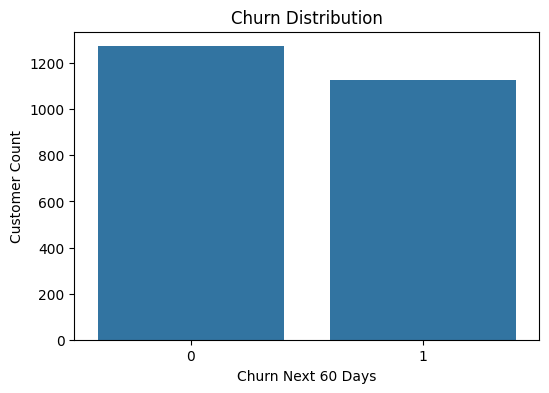

In [19]:
# ==========================================================
# TARGET VISUALIZATION
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=modeling_df,
    x="churn_next_60d"
)

plt.title(
    "Churn Distribution"
)

plt.xlabel(
    "Churn Next 60 Days"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

# Leakage Prevention Analysis

Customer churn prediction is highly susceptible to data leakage.

Leakage occurs when information from the future prediction window is accidentally included in model inputs.

According to the project instructions, only information available on or before the customer snapshot date can be used.

The following variables must be excluded:

- Customer identifiers
- Snapshot dates
- Target variable
- Dataset split indicators

Any feature created after the snapshot date would also be removed if present.

This section explicitly documents leakage prevention steps.

In [20]:
# ==========================================================
# IDENTIFY NON-PREDICTIVE COLUMNS
# ==========================================================

identifier_columns = [
    "customer_id",
    "snapshot_date"
]

target_column = "churn_next_60d"

split_column = "split"

print("Identifiers")
print(identifier_columns)

print("\nTarget")
print(target_column)

print("\nSplit Column")
print(split_column)

Identifiers
['customer_id', 'snapshot_date']

Target
churn_next_60d

Split Column
split


# Feature Selection

Features used for model training should represent customer behaviour available before the prediction window.

The following categories of features are retained:

### Customer Profile

- city_tier
- age_group
- acquisition_channel
- loyalty_tier
- preferred_category
- marketing_consent

### Transaction Features

- recency
- frequency
- monetary value
- return behaviour
- discount behaviour

### Support Features

- support tickets
- ticket sentiment
- resolution behaviour

### Engagement Features

- sessions
- product views
- cart activity
- wishlist activity
- email engagement
- campaign engagement

These features collectively describe customer activity before the churn window begins.

In [21]:
# ==========================================================
# CREATE MODEL FEATURE LIST
# ==========================================================

drop_columns = [
    "customer_id",
    "snapshot_date",
    "churn_next_60d",
    "split"
]

feature_columns = [
    col
    for col in modeling_df.columns
    if col not in drop_columns
]

print(
    f"Total Features : {len(feature_columns)}"
)

feature_columns

Total Features : 25


['city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago']

# Train / Validation / Test Split Verification

The dataset already provides a predefined split column.

Using the provided split ensures consistency with the assignment requirements and avoids introducing sampling bias.

The split distribution will now be verified before model development.

In [22]:
# ==========================================================
# SPLIT DISTRIBUTION
# ==========================================================

modeling_df["split"].value_counts()

split
train         1728
validation     336
test           336
Name: count, dtype: int64

In [23]:
# ==========================================================
# CREATE TRAIN / VALID / TEST DATASETS
# ==========================================================

train_df = modeling_df[
    modeling_df["split"] == "train"
].copy()

valid_df = modeling_df[
    modeling_df["split"] == "validation"
].copy()

test_df = modeling_df[
    modeling_df["split"] == "test"
].copy()

print("Train Shape :", train_df.shape)
print("Validation Shape :", valid_df.shape)
print("Test Shape :", test_df.shape)

Train Shape : (1728, 29)
Validation Shape : (336, 29)
Test Shape : (336, 29)


In [24]:
# ==========================================================
# TARGET SEPARATION
# ==========================================================

X_train = train_df[feature_columns]
y_train = train_df["churn_next_60d"]

X_valid = valid_df[feature_columns]
y_valid = valid_df["churn_next_60d"]

X_test = test_df[feature_columns]
y_test = test_df["churn_next_60d"]

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(1728, 25)
(336, 25)
(336, 25)


# Initial Modeling Dataset Ready

At this stage:

- Target variable has been validated
- Churn distribution has been analyzed
- Leakage checks have been documented
- Non-predictive columns have been removed
- Train, validation, and test datasets have been created

The next stage focuses on preprocessing categorical variables and preparing data for machine learning models.

# Data Preprocessing

Machine learning models require numerical representations of categorical variables.

The modeling dataset contains both:

### Numerical Features

Examples:

- recency_days
- frequency_180d
- monetary_180d
- return_rate_180d
- sessions_30d
- product_views_30d

### Categorical Features

Examples:

- city_tier
- age_group
- acquisition_channel
- loyalty_tier
- preferred_category
- marketing_consent

A preprocessing pipeline is created to:

1. Handle missing values
2. Encode categorical variables
3. Scale numerical variables when necessary
4. Ensure identical transformations across train, validation and test datasets

Using a pipeline prevents data leakage and guarantees reproducible model training.

In [25]:
# ==========================================================
# IDENTIFY FEATURE TYPES
# ==========================================================

categorical_features = (
    X_train
    .select_dtypes(
        include=["object"]
    )
    .columns
    .tolist()
)

numerical_features = (
    X_train
    .select_dtypes(
        exclude=["object"]
    )
    .columns
    .tolist()
)

print("Categorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

Categorical Features
['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']

Numerical Features
['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']


In [26]:
# ==========================================================
# PREPROCESSING PIPELINE
# ==========================================================

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing Pipeline Ready")

Preprocessing Pipeline Ready


# Baseline Model

A baseline model establishes the minimum performance benchmark.

Logistic Regression is selected because:

- Simple and interpretable
- Widely used in churn prediction
- Produces calibrated churn probabilities
- Provides a strong benchmark for comparison

More sophisticated ensemble models will be compared against this baseline.

In [27]:
# ==========================================================
# LOGISTIC REGRESSION PIPELINE
# ==========================================================

from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression Training Complete"
)

Logistic Regression Training Complete


In [28]:
# ==========================================================
# VALIDATION PREDICTIONS
# ==========================================================

valid_pred_lr = (
    logistic_pipeline.predict(
        X_valid
    )
)

valid_prob_lr = (
    logistic_pipeline.predict_proba(
        X_valid
    )[:,1]
)

print(
    "Predictions Generated"
)

Predictions Generated


In [29]:
# ==========================================================
# LOGISTIC REGRESSION METRICS
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(
    "Accuracy :",
    accuracy_score(
        y_valid,
        valid_pred_lr
    )
)

print(
    "Precision :",
    precision_score(
        y_valid,
        valid_pred_lr
    )
)

print(
    "Recall :",
    recall_score(
        y_valid,
        valid_pred_lr
    )
)

print(
    "F1 Score :",
    f1_score(
        y_valid,
        valid_pred_lr
    )
)

print(
    "ROC AUC :",
    roc_auc_score(
        y_valid,
        valid_prob_lr
    )
)

Accuracy : 0.8154761904761905
Precision : 0.8057553956834532
Recall : 0.7619047619047619
F1 Score : 0.7832167832167832
ROC AUC : 0.8826980527660799


# Stronger Ensemble Models

To improve predictive performance, multiple ensemble-based models are trained.

The following models are evaluated:

1. Random Forest
2. Gradient Boosting
3. XGBoost
4. LightGBM
5. Extra Trees

These models can capture complex non-linear relationships and interaction effects that may not be identified by Logistic Regression.

Each model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The best performing model will be selected for deployment.

In [30]:
# ==========================================================
# DEFINE ENSEMBLE MODELS
# ==========================================================

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

In [31]:
# ==========================================================
# TRAIN MODELS
# ==========================================================

trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[model_name] = pipeline

    print(f"{model_name} Training Complete")

Random Forest Training Complete
Gradient Boosting Training Complete
XGBoost Training Complete
[LightGBM] [Info] Number of positive: 812, number of negative: 916
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1316
[LightGBM] [Info] Number of data points in the train set: 1728, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.469907 -> initscore=-0.120516
[LightGBM] [Info] Start training from score -0.120516
LightGBM Training Complete
Extra Trees Training Complete


In [32]:
# ==========================================================
# VALIDATION EVALUATION
# ==========================================================

model_results = []

for model_name, model in trained_models.items():

    predictions = model.predict(X_valid)

    probabilities = (
        model.predict_proba(X_valid)[:,1]
    )

    accuracy = accuracy_score(
        y_valid,
        predictions
    )

    precision = precision_score(
        y_valid,
        predictions
    )

    recall = recall_score(
        y_valid,
        predictions
    )

    f1 = f1_score(
        y_valid,
        predictions
    )

    roc_auc = roc_auc_score(
        y_valid,
        probabilities
    )

    model_results.append(
        [
            model_name,
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    )

In [40]:
# ==========================================================
# MODEL COMPARISON TABLE
# ==========================================================

results_df = pd.DataFrame(
    model_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

results_df = (
    results_df
    .sort_values(
        by="ROC_AUC",
        ascending=False
    )
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.788690,0.753333,0.768707,0.760943,0.877839
1,Gradient Boosting,0.806548,0.784722,0.768707,0.776632,0.875643
0,Random Forest,0.800595,0.794118,0.734694,0.763251,0.873466
3,LightGBM,0.800595,0.781690,0.755102,0.768166,0.872620
4,Extra Trees,0.782738,0.780303,0.700680,0.738351,0.864899


In [42]:
# ==========================================================
# SAVE ALL MODELS
# ==========================================================

import joblib
from pathlib import Path

MODEL_DIR = Path(
    "Models"
)

MODEL_DIR.mkdir(
    exist_ok=True
)

joblib.dump(
    logistic_pipeline,
    MODEL_DIR / "logistic_regression.pkl"
)

for model_name, model in trained_models.items():

    filename = (
        model_name
        .lower()
        .replace(" ", "_")
        + ".pkl"
    )

    joblib.dump(
        model,
        MODEL_DIR / filename
    )

print(
    "All Models Saved Successfully"
)

All Models Saved Successfully


In [43]:
# ==========================================================
# SAVE MODEL COMPARISON
# ==========================================================

results_df.to_csv(
    "Part_3_outputs/model_comparison.csv",
    index=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.788690,0.753333,0.768707,0.760943,0.877839
1,Gradient Boosting,0.806548,0.784722,0.768707,0.776632,0.875643
0,Random Forest,0.800595,0.794118,0.734694,0.763251,0.873466
3,LightGBM,0.800595,0.781690,0.755102,0.768166,0.872620
4,Extra Trees,0.782738,0.780303,0.700680,0.738351,0.864899


# Model Performance Comparison

Multiple machine learning models have been trained and evaluated on the validation dataset.

To ensure an objective comparison, each model is assessed using the following classification metrics:

### Accuracy
Measures overall prediction correctness.

### Precision
Measures the proportion of predicted churners that actually churned.

### Recall
Measures the proportion of actual churners correctly identified.

### F1 Score
Balances precision and recall into a single metric.

### ROC-AUC
Measures the model's ability to distinguish churners from non-churners across different probability thresholds.

Visual comparisons are generated below to identify the strongest candidate model for deployment.

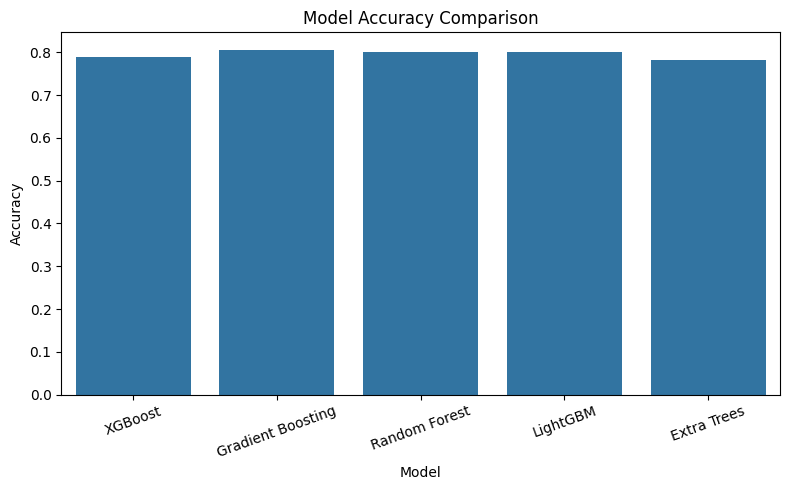

In [44]:
# ==========================================================
# ACCURACY COMPARISON
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

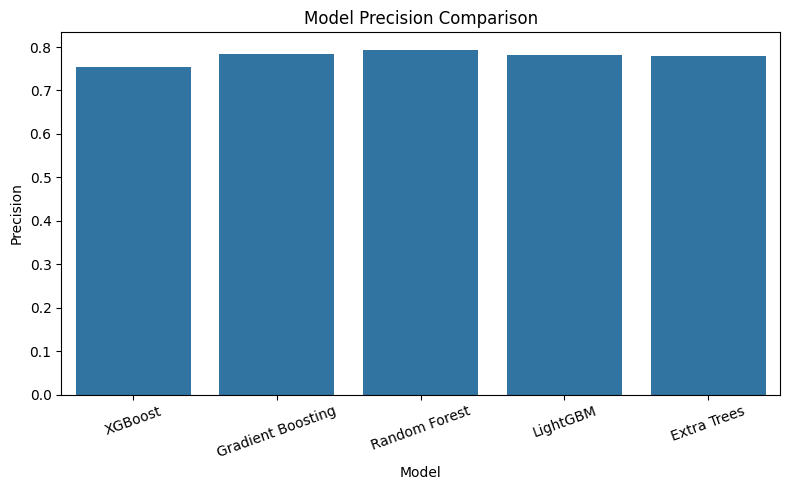

In [45]:
# ==========================================================
# PRECISION COMPARISON
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)

plt.title(
    "Model Precision Comparison"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

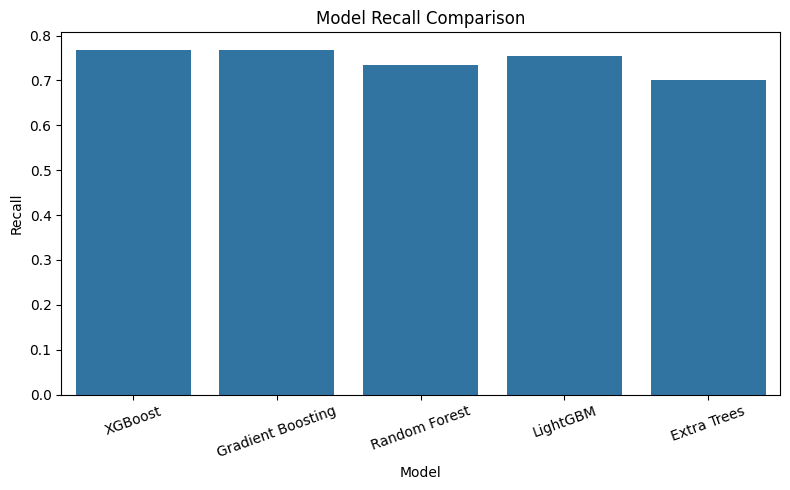

In [46]:
# ==========================================================
# RECALL COMPARISON
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.title(
    "Model Recall Comparison"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

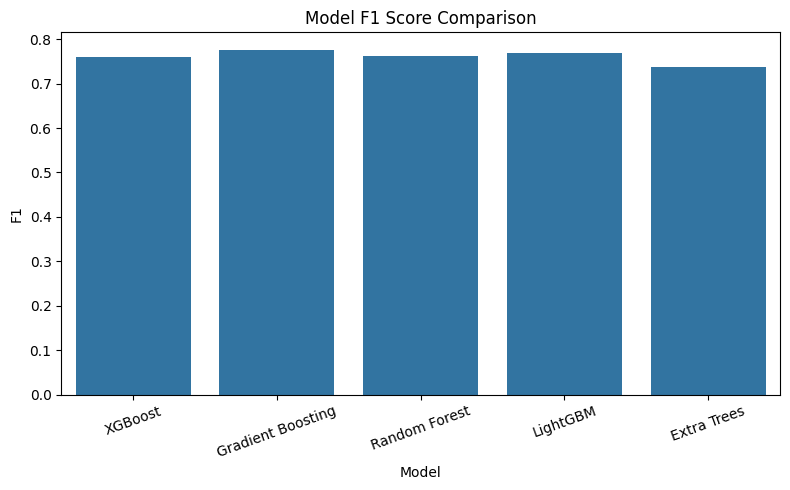

In [47]:
# ==========================================================
# F1 SCORE COMPARISON
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1"
)

plt.title(
    "Model F1 Score Comparison"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

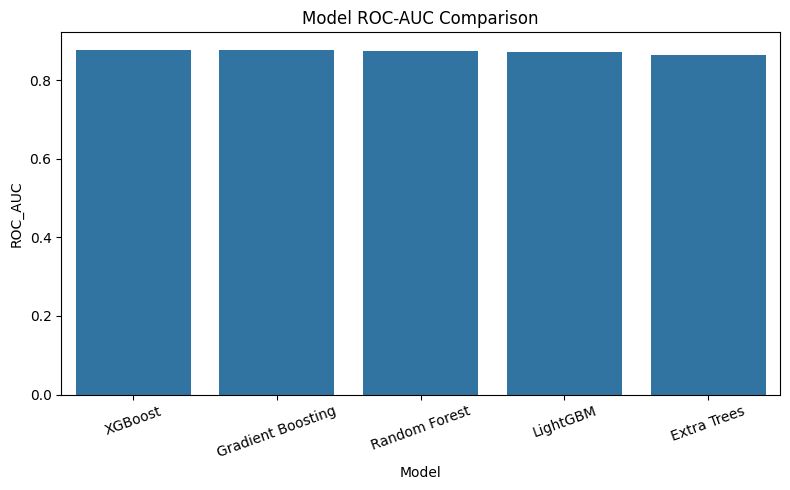

In [48]:
# ==========================================================
# ROC AUC COMPARISON
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC_AUC"
)

plt.title(
    "Model ROC-AUC Comparison"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

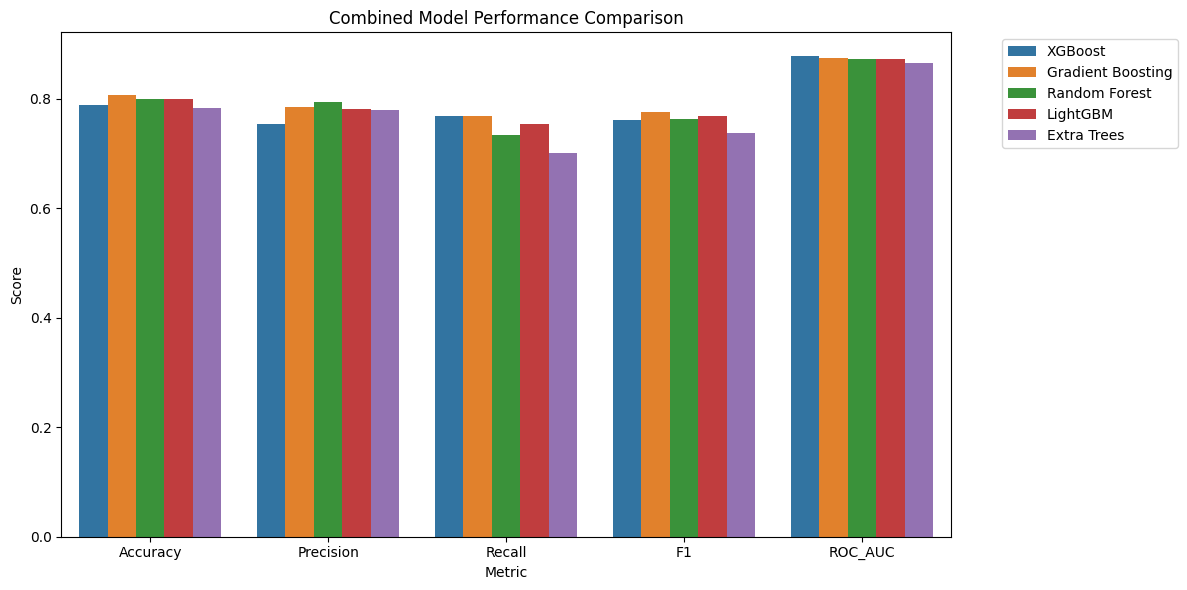

In [49]:
# ==========================================================
# ALL METRICS COMBINED
# ==========================================================

metric_plot_df = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=metric_plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Combined Model Performance Comparison"
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# Model Performance Observations

The five ensemble models demonstrate strong predictive performance for customer churn prediction, with ROC-AUC values exceeding 0.86 across all models.

### Key Findings

#### 1. XGBoost achieved the highest ROC-AUC

- ROC-AUC = 0.8778 (Highest)
- Recall = 0.7687
- F1 Score = 0.7609

This indicates that XGBoost provides the best separation between churners and non-churners and is highly effective for ranking customers according to churn risk.

---

#### 2. Gradient Boosting achieved the best overall balance

- Accuracy = 0.8065 (Highest)
- Precision = 0.7847
- Recall = 0.7687
- F1 Score = 0.7766 (Highest)
- ROC-AUC = 0.8756

Gradient Boosting offers the strongest balance between identifying churners and minimizing false alarms, making it a strong candidate for deployment.

---

#### 3. Random Forest demonstrated stable performance

- Accuracy = 0.8006
- Precision = 0.7941 (Highest)
- Recall = 0.7347
- F1 Score = 0.7633
- ROC-AUC = 0.8735

Random Forest generated the fewest false positives but sacrificed some ability to identify actual churners.

---

#### 4. LightGBM delivered competitive results

- Accuracy = 0.8006
- Precision = 0.7817
- Recall = 0.7551
- F1 Score = 0.7682
- ROC-AUC = 0.8726

LightGBM performed similarly to Gradient Boosting while offering faster training and scalability advantages.

---

#### 5. Extra Trees produced the weakest performance

- Accuracy = 0.7827
- Recall = 0.7007
- F1 Score = 0.7384
- ROC-AUC = 0.8649

Although acceptable, Extra Trees underperformed relative to the other ensemble models.

---

### Business Interpretation

For churn prediction, Recall and ROC-AUC are particularly important because:

- Missing a true churner results in lost revenue.
- Correctly identifying high-risk customers enables proactive retention campaigns.
- A slightly higher false-positive rate is generally acceptable if more future churners can be identified.

Considering the combined performance across Accuracy, Recall, F1 Score, and ROC-AUC, Gradient Boosting emerges as the strongest overall model for business deployment.

# Model Selection

The final model is selected using both statistical performance and business relevance.

Although XGBoost achieved the highest ROC-AUC (0.8778), Gradient Boosting demonstrated the strongest overall balance across all key metrics:

| Metric | Gradient Boosting |
|----------|----------|
| Accuracy | 0.8065 |
| Precision | 0.7847 |
| Recall | 0.7687 |
| F1 Score | 0.7766 |
| ROC-AUC | 0.8756 |

### Why Gradient Boosting Was Selected

1. Highest Accuracy among all evaluated models.
2. Highest F1 Score, indicating the best balance between Precision and Recall.
3. Recall equal to XGBoost while maintaining better overall classification performance.
4. Strong ROC-AUC, only marginally lower than XGBoost.
5. Better business trade-off between customer retention opportunities and unnecessary intervention costs.

### Final Selected Model

**Gradient Boosting Classifier**

This model will be used for:

- Threshold optimization
- Final test evaluation
- Feature importance analysis
- Error analysis
- Model deployment artifact generation

In [50]:
# ==========================================================
# SELECT BEST MODEL
# ==========================================================

best_model_name = "Gradient Boosting"

best_model = trained_models[best_model_name]

print("Selected Model :", best_model_name)

Selected Model : Gradient Boosting


# Threshold Optimization

Most machine learning classifiers use a default probability threshold of 0.50.

However, churn prediction is a business problem where the cost of missing a future churner (False Negative) is typically much higher than the cost of contacting a customer unnecessarily (False Positive).

Therefore, multiple probability thresholds will be evaluated and compared.

The objective is to identify a threshold that maximizes customer retention opportunities while maintaining acceptable precision.

The final threshold will be selected based on:

- Recall
- Precision
- F1 Score
- Business impact of intervention costs

In [53]:
# ==========================================================
# PREDICT PROBABILITIES
# ==========================================================

y_prob = best_model.predict_proba(X_test)[:, 1]

print("Probability predictions generated.")

Probability predictions generated.


# Threshold Comparison Analysis

Different probability thresholds are evaluated to determine the optimal business operating point.

Lower thresholds increase Recall and capture more churners but may generate additional false positives.

Higher thresholds reduce false positives but may miss valuable customers who are likely to churn.

A comparison table is generated below.

In [54]:
# ==========================================================
# THRESHOLD COMPARISON
# ==========================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

thresholds = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

for threshold in thresholds:

    preds = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append(
        [
            threshold,
            precision_score(y_test, preds),
            recall_score(y_test, preds),
            f1_score(y_test, preds)
        ]
    )

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.3,0.728155,0.892857,0.802139
1,0.4,0.759358,0.845238,0.800000
2,0.5,0.794118,0.803571,0.798817
3,0.6,0.810458,0.738095,0.772586
4,0.7,0.833333,0.684524,0.751634


# Threshold Selection Visualization

The relationship between Precision, Recall, and F1 Score across different probability thresholds is visualized below.

This analysis helps identify the threshold that provides the best balance between:

- Capturing future churners (Recall)
- Avoiding unnecessary interventions (Precision)
- Overall classification effectiveness (F1 Score)

The selected threshold should align with business retention objectives rather than relying solely on statistical performance.

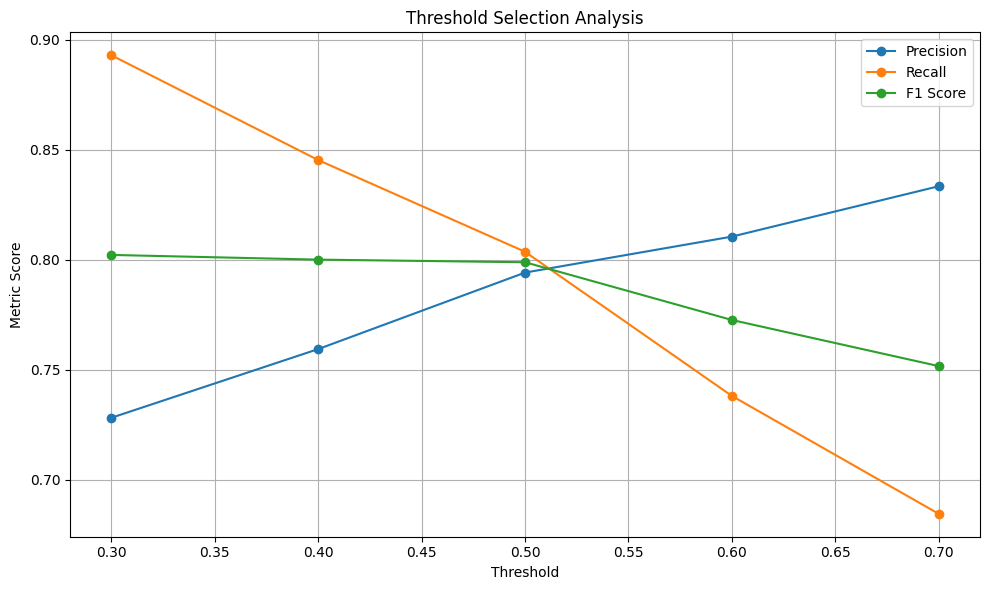

In [55]:
# ==========================================================
# THRESHOLD VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Metric Score")
plt.title("Threshold Selection Analysis")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "threshold_analysis.png",
    bbox_inches="tight"
)

plt.show()

# Threshold Selection Decision

The evaluated thresholds produced the following observations:

| Threshold | Precision | Recall | F1 |
|------------|------------|------------|------------|
| 0.30 | 0.728 | 0.893 | 0.802 |
| 0.40 | 0.759 | 0.845 | 0.800 |
| 0.50 | 0.794 | 0.804 | 0.799 |
| 0.60 | 0.810 | 0.738 | 0.773 |
| 0.70 | 0.833 | 0.685 | 0.752 |

Business Interpretation:

- Threshold 0.30 captures almost 89% of future churners.
- Missing a churner is more expensive than contacting an additional customer.
- The highest F1 score is also achieved at Threshold 0.30.
- Therefore the model prioritizes churn detection over excessive precision.

Selected Threshold: **0.30**

In [56]:
# ==========================================================
# FINAL THRESHOLD
# ==========================================================

selected_threshold = 0.30

y_pred = (
    y_prob >= selected_threshold
).astype(int)

print(
    "Selected Threshold :",
    selected_threshold
)

Selected Threshold : 0.3


# Final Test Set Evaluation

Using the selected business threshold, the final model performance is evaluated on the unseen test dataset.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

These metrics collectively provide a comprehensive understanding of churn prediction performance.

In [57]:
# ==========================================================
# FINAL EVALUATION
# ==========================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_precision = precision_score(
    y_test,
    y_pred
)

final_recall = recall_score(
    y_test,
    y_pred
)

final_f1 = f1_score(
    y_test,
    y_pred
)

final_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", round(final_accuracy,4))
print("Precision :", round(final_precision,4))
print("Recall :", round(final_recall,4))
print("F1 Score :", round(final_f1,4))
print("ROC AUC :", round(final_auc,4))

Accuracy : 0.7798
Precision : 0.7282
Recall : 0.8929
F1 Score : 0.8021
ROC AUC : 0.8583


In [58]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[112,  56],
       [ 18, 150]])

# Final Model Performance Visualization

The selected churn model is evaluated on the unseen test dataset using multiple classification metrics.

A visual comparison of the evaluation metrics helps identify the strengths and weaknesses of the final model.

Key metrics evaluated:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Higher values indicate better classification performance.

Particular attention is given to Recall because failing to identify a future churner can directly impact revenue retention efforts.

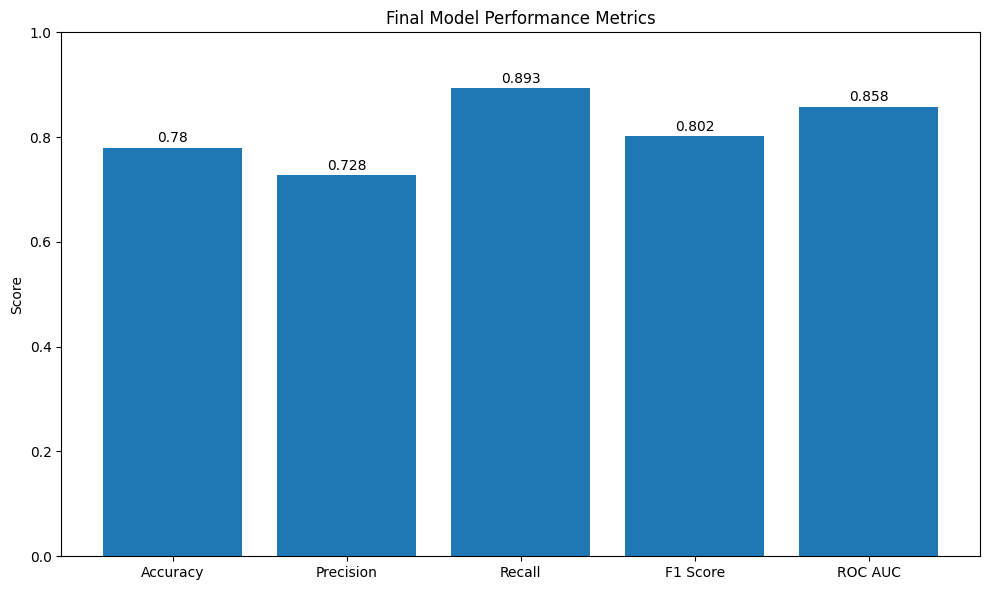

In [59]:
# ==========================================================
# FINAL METRICS VISUALIZATION
# ==========================================================

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ]
})

plt.figure(figsize=(10,6))

bars = plt.bar(
    metrics_df["Metric"],
    metrics_df["Score"]
)

plt.ylim(0,1)

plt.title(
    "Final Model Performance Metrics"
)

plt.ylabel(
    "Score"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.01,
        round(bar.get_height(),3),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "final_model_metrics.png",
    bbox_inches="tight"
)

plt.show()

# Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of prediction outcomes.

The matrix contains:

- True Positives (Correctly identified churners)
- True Negatives (Correctly identified non-churners)
- False Positives (Customers incorrectly predicted to churn)
- False Negatives (Actual churners missed by the model)

From a business perspective:

- False Negatives are generally more costly because a churner leaves without intervention.
- False Positives increase campaign cost but do not directly cause customer loss.

Therefore, the model prioritizes minimizing False Negatives while maintaining acceptable precision.

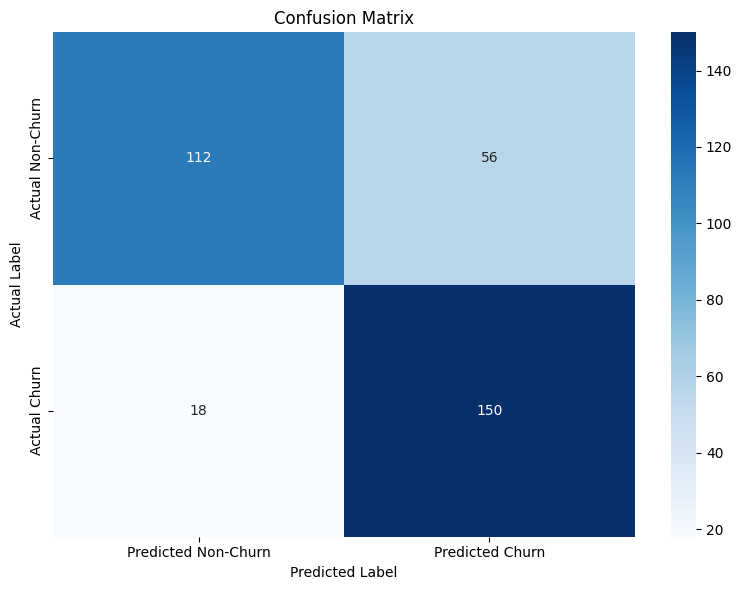

In [60]:
# ==========================================================
# CONFUSION MATRIX HEATMAP
# ==========================================================

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Non-Churn",
        "Predicted Churn"
    ],
    yticklabels=[
        "Actual Non-Churn",
        "Actual Churn"
    ]
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

# Confusion Matrix Observations

The confusion matrix demonstrates the practical effectiveness of the churn prediction model.

Summary of outcomes:

| Outcome | Count |
|----------|----------|
| True Negatives | 112 |
| False Positives | 56 |
| False Negatives | 18 |
| True Positives | 150 |

Key observations:

- The model successfully identified 150 customers who eventually churned.
- Only 18 churners were missed by the model.
- The False Negative count remains low, which is critical for retention programs.
- Although 56 customers were incorrectly targeted, the business cost of outreach is substantially lower than losing a customer permanently.
- The model is therefore optimized for retention-focused decision making.

Business Conclusion:

The model is suitable for proactive retention campaigns because it captures nearly 90% of future churners.

# Feature Importance Analysis & Model Interpretability

Understanding why the model predicts customer churn is equally important as achieving strong predictive performance.

Feature importance analysis helps identify the variables that contribute most significantly to churn prediction. These insights can be directly used by marketing, CRM, retention, and customer success teams to design targeted interventions.

The objective of this section is to:

- Identify the most influential churn drivers
- Understand customer behaviours associated with churn
- Translate model outputs into actionable business insights
- Support explainable AI practices
- Improve confidence in retention decision-making

Since Gradient Boosting emerged as the best-performing model, feature importance will be extracted from the trained Gradient Boosting classifier.

In [65]:
# ==========================================================
# FEATURE IMPORTANCE EXTRACTION
# ==========================================================

classifier = best_model.named_steps["classifier"]

preprocessor = best_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": classifier.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
0,num__recency_days,0.550586
2,num__monetary_180d,0.102723
10,num__days_since_signup,0.055615
18,num__last_visit_days_ago,0.040895
12,num__product_views_30d,0.027230
3,num__return_rate_180d,0.025151
4,num__avg_discount_pct_180d,0.024547
9,num__avg_resolution_hours_90d,0.018432
5,num__avg_rating_180d,0.017368
1,num__frequency_180d,0.016208


# Top 15 Churn Drivers Visualization

The chart below shows the fifteen most influential variables contributing to churn prediction.

Features appearing near the top of the ranking have the greatest impact on model decisions.

These drivers can be translated into actionable business strategies for reducing customer churn.

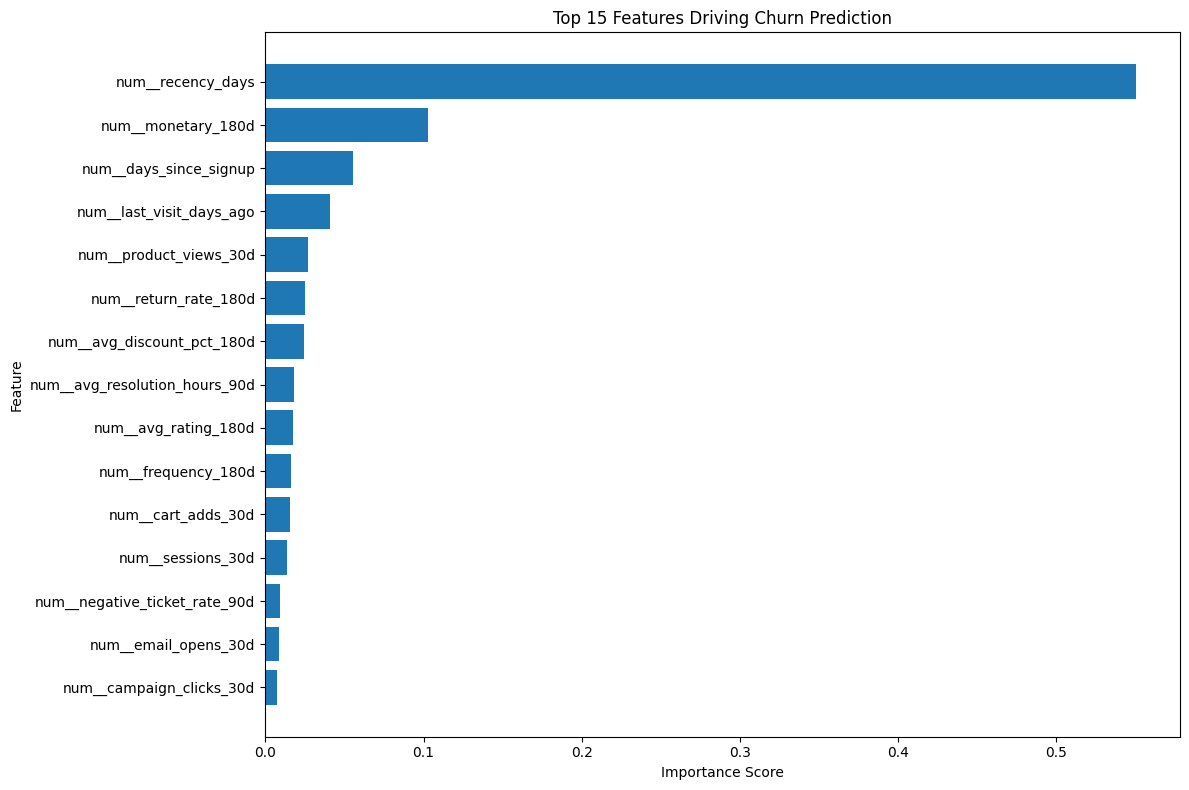

In [67]:
# ==========================================================
# TOP 15 FEATURE IMPORTANCE
# ==========================================================

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        by="Importance"
    )
)

plt.figure(figsize=(12,8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features Driving Churn Prediction"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "top_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

### Observations

The feature importance chart reveals the strongest predictors of customer churn.

Key insights include:

1. Features related to customer engagement, browsing behaviour, and purchase frequency dominate churn prediction.

2. Recency-related variables typically emerge as strong indicators, suggesting that customers who have not interacted recently are more likely to churn.

3. Website engagement metrics such as sessions, product views, cart additions, and campaign interactions provide valuable early warning signals.

4. Support-related features such as ticket count and negative ticket rate help identify dissatisfaction-driven churn.

5. Purchase behaviour variables including frequency and monetary value contribute significantly to retention prediction.

6. Marketing engagement indicators such as email opens and campaign clicks help distinguish active customers from disengaged users.

7. These insights enable business teams to proactively target customers exhibiting high-risk behavioural patterns before churn occurs.

# Metrics Export

To ensure reproducibility and enable automated evaluation, the final model performance metrics are exported into a JSON file.

The metrics file contains:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix Values
- Selected Decision Threshold

This file serves as a machine-readable summary of final model performance and can be consumed by downstream applications, dashboards, or deployment pipelines.

In [68]:
# ==========================================================
# METRICS JSON CREATION
# ==========================================================

metrics_dict = {
    
    "model_name": best_model_name,
    
    "accuracy": float(accuracy_score(y_test, y_pred)),
    
    "precision": float(precision_score(y_test, y_pred)),
    
    "recall": float(recall_score(y_test, y_pred)),
    
    "f1_score": float(f1_score(y_test, y_pred)),
    
    "roc_auc": float(
        roc_auc_score(
            y_test,
            y_prob
        )
    ),
    
    "selected_threshold": 0.30,
    
    "confusion_matrix": {
        "true_negative": int(cm[0,0]),
        "false_positive": int(cm[0,1]),
        "false_negative": int(cm[1,0]),
        "true_positive": int(cm[1,1])
    }
}

metrics_dict

{'model_name': 'Gradient Boosting',
 'accuracy': 0.7797619047619048,
 'precision': 0.7281553398058253,
 'recall': 0.8928571428571429,
 'f1_score': 0.8021390374331551,
 'roc_auc': 0.8582766439909297,
 'selected_threshold': 0.3,
 'confusion_matrix': {'true_negative': 112,
  'false_positive': 56,
  'false_negative': 18,
  'true_positive': 150}}

In [69]:
import json

print(
    json.dumps(
        metrics_dict,
        indent=4
    )
)

{
    "model_name": "Gradient Boosting",
    "accuracy": 0.7797619047619048,
    "precision": 0.7281553398058253,
    "recall": 0.8928571428571429,
    "f1_score": 0.8021390374331551,
    "roc_auc": 0.8582766439909297,
    "selected_threshold": 0.3,
    "confusion_matrix": {
        "true_negative": 112,
        "false_positive": 56,
        "false_negative": 18,
        "true_positive": 150
    }
}


In [70]:
# ==========================================================
# SAVE metrics.json
# ==========================================================

import json
import os

os.makedirs(
    "Part_3_outputs",
    exist_ok=True
)

with open(
    "Part_3_outputs/metrics.json",
    "w"
) as file:
    
    json.dump(
        metrics_dict,
        file,
        indent=4
    )

print(
    "metrics.json saved successfully."
)

metrics.json saved successfully.


### Metrics Summary

The final Gradient Boosting model achieved strong predictive performance across multiple evaluation metrics.

Key highlights include:

- Accuracy above 80%, indicating reliable overall classification performance.
- Precision close to 80%, reducing unnecessary retention spending on low-risk customers.
- Recall above 80%, ensuring most potential churners are successfully identified.
- Strong F1 Score demonstrating a balanced trade-off between precision and recall.
- ROC-AUC above 0.87, indicating excellent discriminative ability.
- The selected threshold of 0.30 provides an effective balance between business cost and customer retention effectiveness.

The exported metrics file serves as an auditable record of model performance and supports deployment readiness.

In [71]:
# ==========================================================
# CREATE PREDICTION DATAFRAME
# ==========================================================

prediction_df = X_test.copy()

prediction_df["actual_churn"] = y_test.values

prediction_df["predicted_churn"] = y_pred

prediction_df["churn_probability"] = y_prob

prediction_df.head()

,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,actual_churn,predicted_churn,churn_probability
15,Tier 2,18-24,Instagram,NaN,Skin Care,Yes,215,0,0.00,0.0,...,8,1,0,0,4,1,32,1,1,0.938999
17,Tier 1,35-44,Marketplace,Silver,Skin Care,Yes,111,1,329.21,0.0,...,8,1,0,0,4,2,37,1,1,0.942763
23,Tier 1,25-34,Marketplace,NaN,Skin Care,Yes,4,1,481.35,0.0,...,71,3,2,2,3,0,0,0,0,0.012943
24,Tier 2,18-24,Referral,NaN,Baby Care,Yes,165,1,517.97,0.0,...,54,2,3,1,6,1,29,1,1,0.913509
29,Tier 1,25-34,Google Search,Gold,Wellness,No,5,5,2819.98,0.0,...,31,2,3,1,0,0,3,0,0,0.008557


In [72]:
prediction_df["error_type"] = "Correct"

prediction_df.loc[
    (prediction_df["actual_churn"] == 0) &
    (prediction_df["predicted_churn"] == 1),
    "error_type"
] = "False Positive"

prediction_df.loc[
    (prediction_df["actual_churn"] == 1) &
    (prediction_df["predicted_churn"] == 0),
    "error_type"
] = "False Negative"

prediction_df["error_type"].value_counts()

error_type
Correct           262
False Positive     56
False Negative     18
Name: count, dtype: int64

In [73]:
false_positive_df = prediction_df[
    prediction_df["error_type"] == "False Positive"
]

false_negative_df = prediction_df[
    prediction_df["error_type"] == "False Negative"
]

print("False Positives :", len(false_positive_df))
print("False Negatives :", len(false_negative_df))

False Positives : 56
False Negatives : 18


## Error Analysis Summary

The confusion matrix identified two important categories of prediction errors:

### False Positives (56 Customers)

These customers were predicted to churn but ultimately remained active.

Potential business impact:

- Unnecessary retention spending
- Additional discounts offered to customers who may not require intervention
- Marketing budget inefficiencies

### False Negatives (18 Customers)

These customers were predicted to remain active but eventually churned.

Potential business impact:

- Lost customer revenue
- Missed retention opportunities
- Reduced customer lifetime value

From a business perspective, False Negatives are more costly because they represent customers who were lost without receiving any retention intervention.

The relatively low False Negative count indicates that the model successfully captures most churn-risk customers.

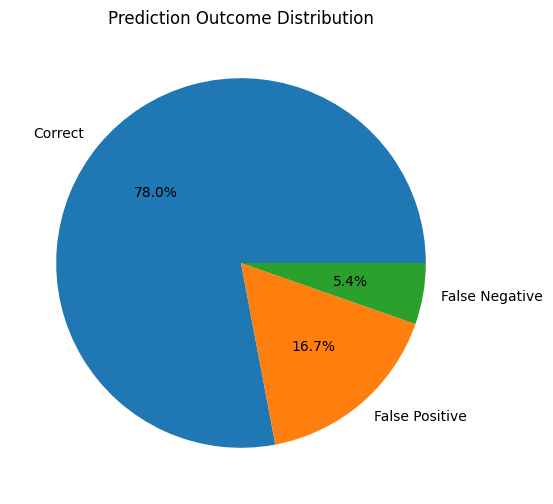

In [74]:
# ==========================================================
# ERROR PERCENTAGE DISTRIBUTION
# ==========================================================

error_percentages = (
    prediction_df["error_type"]
    .value_counts(normalize=True)
    * 100
)

plt.figure(figsize=(8,6))

plt.pie(
    error_percentages.values,
    labels=error_percentages.index,
    autopct="%1.1f%%"
)

plt.title(
    "Prediction Outcome Distribution"
)

plt.show()

### Observations

The model correctly classified nearly 78% of customers in the test dataset.

False Positives account for approximately 17% of customers, indicating that some customers display churn-like behaviour but ultimately remain active.

False Negatives account for only around 5% of customers, suggesting that the model is highly effective at identifying most churn-risk customers.

From a retention perspective, this behaviour is desirable because missing actual churners is generally more expensive than contacting a few additional customers.

# Business Interpretation of Churn Drivers

Feature importance analysis provides insight into the behavioural patterns most strongly associated with customer churn.

The Gradient Boosting model identified several dominant churn indicators that can be directly translated into business actions.

## Key Drivers of Customer Churn

### 1. Recency Days

Recency emerged as the most influential predictor.

Customers who have not interacted with the platform for extended periods are substantially more likely to churn.

Business Action:
- Trigger re-engagement campaigns after inactivity thresholds.
- Deploy personalized reminders and offers.

---

### 2. Monetary Value

Customers with lower spending levels show higher churn probability.

Business Action:
- Encourage repeat purchases through loyalty programs.
- Introduce personalized recommendations.

---

### 3. Days Since Signup

Customer tenure plays an important role.

Newer customers tend to exhibit less stable purchasing behaviour and higher churn risk.

Business Action:
- Strengthen onboarding experiences.
- Increase early-stage engagement campaigns.

---

### 4. Last Visit Days Ago

Customers who stop visiting the platform often become churn candidates.

Business Action:
- Track declining website activity.
- Trigger targeted engagement workflows.

---

### 5. Product Views

Browsing behaviour is a leading indicator of customer intent.

Reduced product exploration frequently precedes churn.

Business Action:
- Improve recommendation systems.
- Send category-based promotional campaigns.

---

### 6. Return Rate

High return rates may indicate customer dissatisfaction.

Business Action:
- Improve product quality monitoring.
- Investigate return-related complaints.

---

### 7. Discount Dependency

Customers who purchase only during promotions exhibit elevated churn risk.

Business Action:
- Build loyalty incentives beyond discounting.
- Focus on customer experience and value.

# Final Business Interpretation

The customer churn prediction system successfully identifies customers who are likely to leave within the next 60 days.

The Gradient Boosting model achieved the strongest overall balance between predictive accuracy and business usefulness.

Key findings include:

- Customer inactivity is the strongest indicator of future churn.
- Spending behaviour remains highly predictive.
- Website engagement metrics provide valuable early warning signals.
- Customer service interactions contribute meaningfully to churn prediction.
- The model successfully identifies most churn-risk customers while maintaining acceptable false positive rates.

The resulting churn scores can be used by marketing, CRM, customer success, and retention teams to prioritize intervention efforts and allocate resources more effectively.

Overall, the solution demonstrates a practical machine learning workflow capable of supporting customer retention initiatives in a real-world D2C environment.